## Imports

In [10]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import sys
import tensorflow
import scipy
from matplotlib import pyplot
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adagrad, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.applications import (
    VGG19, VGG16, EfficientNetB7, DenseNet201, ResNet50, 
    InceptionV3, InceptionResNetV2, NASNetLarge
)
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras import layers, models, callbacks

In [12]:
train_dir = 'C:/Users/Ramy/Desktop/Stage/Data/Archeozoology/Data/Carnivoresx30/conv/train'        
validation_dir = 'C:/Users/Ramy/Desktop/Stage/Data/Archeozoology/Data/Carnivoresx30/conv/validation' 

In [13]:
physical_devices = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)


In [ ]:
#nombre_de_classes = nombre_de_dossiers 
# compter le nombre de fichiers = nombre de photos

In [14]:
from tensorflow.keras.applications.resnet import preprocess_input 

#from keras.applications.imagenet_utils import decode_predictions, preprocess_input#for efficient Net

#Let's train our network using data augmentation and dropout:
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input )#OJO!!!! imagenet_utils for Efficient Net

# Note that the validation data should not be augmented!
test_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)#OJO!!!

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized 
        target_size=(250, 200),
        batch_size=32,
        class_mode='categorical',# put "categorical" si son más de 2 categorías
)

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(250, 200),
        batch_size=20,
        class_mode='categorical',
        shuffle=False,
)

Found 1170 images belonging to 5 classes.


Found 390 images belonging to 5 classes.


In [15]:
x_tr, y_tr = next(train_generator)
x_t, y_t = next(validation_generator)
print(x_tr.shape, 'train samples')
print(x_t.shape, 'test samples')

(32, 250, 200, 3) train samples
(20, 250, 200, 3) test samples


In [16]:
datagenTrain=train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 40x160
        target_size=(250,200),
        batch_size=1170,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='categorical')
datagenTest=test_datagen.flow_from_directory(
        # This is the target directory
        validation_dir,
        # All images will be resized to 40x160
        target_size=(250, 200),
        batch_size=390,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='categorical',
        shuffle=False)
x_train, y_train = next(datagenTrain)
x_test, y_test = next(datagenTest)
print(x_train.shape, 'train samples')
print(x_test.shape, 'test samples')

Found 1170 images belonging to 5 classes.
Found 390 images belonging to 5 classes.
(1170, 250, 200, 3) train samples
(390, 250, 200, 3) test samples


## Choix du Modèle ##

In [17]:
# for transfer learning RESNET50
# define cnn model
def define_model():
	# load model
	model = ResNet50(weights='imagenet',include_top=False, input_shape=(250, 200, 3))
	# mark loaded layers as not trainable
	for layer in model.layers:
		layer.trainable = False
	# add new classifier layers
	flat1 = Flatten()(model.layers[-1].output)
	class1 = Dense(128, activation='relu', kernel_initializer='he_uniform')(flat1)
	output = Dense(5, activation='softmax')(class1)
	# define new model
	model = Model(inputs=model.inputs, outputs=output)
	# compile model
	opt = SGD(learning_rate=0.001, momentum=0.9)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model

# define model
model = define_model()

## Running the Model ##

In [18]:
with tf.device('/GPU:0'):
    history = model.fit(
        train_generator,
        steps_per_epoch=30,
        epochs=100,
        validation_data=validation_generator,
        validation_steps=15
    )

Epoch 1/100
30/30 [==============================] - 41s 1s/step - loss: 1.6420 - accuracy: 0.5476 - val_loss: 0.8482 - val_accuracy: 0.6167
Epoch 2/100
30/30 [==============================] - 37s 1s/step - loss: 0.6093 - accuracy: 0.7696 - val_loss: 0.8251 - val_accuracy: 0.6833
Epoch 3/100
30/30 [==============================] - 40s 1s/step - loss: 0.4878 - accuracy: 0.8083 - val_loss: 0.5714 - val_accuracy: 0.7533
Epoch 4/100
30/30 [==============================] - 41s 1s/step - loss: 0.4539 - accuracy: 0.8260 - val_loss: 0.5115 - val_accuracy: 0.7867
Epoch 5/100
30/30 [==============================] - 38s 1s/step - loss: 0.4059 - accuracy: 0.8457 - val_loss: 0.5105 - val_accuracy: 0.8000
Epoch 6/100
30/30 [==============================] - 38s 1s/step - loss: 0.3940 - accuracy: 0.8488 - val_loss: 0.5538 - val_accuracy: 0.8167
Epoch 7/100
30/30 [==============================] - 37s 1s/step - loss: 0.3728 - accuracy: 0.8584 - val_loss: 0.4645 - val_accuracy: 0.8167
Epoch 8/100
3

In [19]:
#save model
model.save('ResNet50_NewData.h5')
    

In [20]:
predictions=model.predict_generator(validation_generator, steps=len(validation_generator), verbose=1)

C:\Users\Ramy\AppData\Local\Temp\ipykernel_25900\1979981568.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(validation_generator, steps=len(validation_generator), verbose=1)


20/20 [==============================] - 9s 414ms/step


In [21]:
import numpy as np
val_preds = np.round(predictions)# from probabilities to 0 or 1
val_trues = validation_generator.classes

In [23]:
#modify:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np
num_of_test_samples = 390 #number of testing samples
batch_size=20 #batch size for the validation set
Y_pred = model.predict_generator(validation_generator, num_of_test_samples // batch_size+1)
y_pred = np.argmax(Y_pred, axis=1)
print('Confusion Matrix')
print(confusion_matrix(validation_generator.classes, y_pred))

C:\Users\Ramy\AppData\Local\Temp\ipykernel_25900\2385629694.py:7: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(validation_generator, num_of_test_samples // batch_size+1)


Confusion Matrix
[[  7   7   4   2   0]
 [  0  81   5   5   0]
 [  0  13 119   4   0]
 [  0   4   3  59   0]
 [  2   0   1   2  72]]


In [24]:
print('Classification Report')
target_names = ['croc', 'hyena', 'leopard', 'lion','Lycaons']
print(classification_report(validation_generator.classes, y_pred, target_names=target_names))

Classification Report
              precision    recall  f1-score   support

        croc       0.78      0.35      0.48        20
       hyena       0.77      0.89      0.83        91
     leopard       0.90      0.88      0.89       136
        lion       0.82      0.89      0.86        66
     Lycaons       1.00      0.94      0.97        77

    accuracy                           0.87       390
   macro avg       0.85      0.79      0.80       390
weighted avg       0.87      0.87      0.86       390



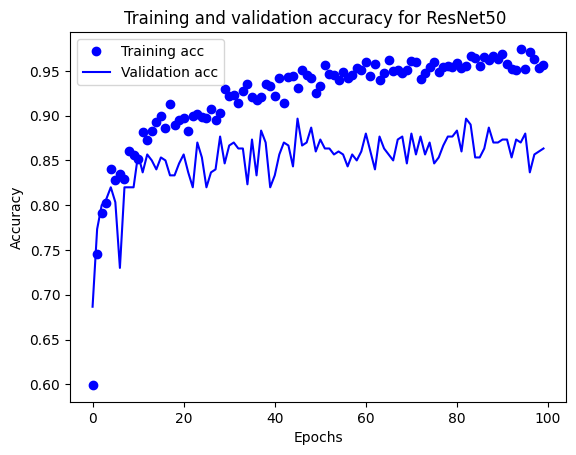

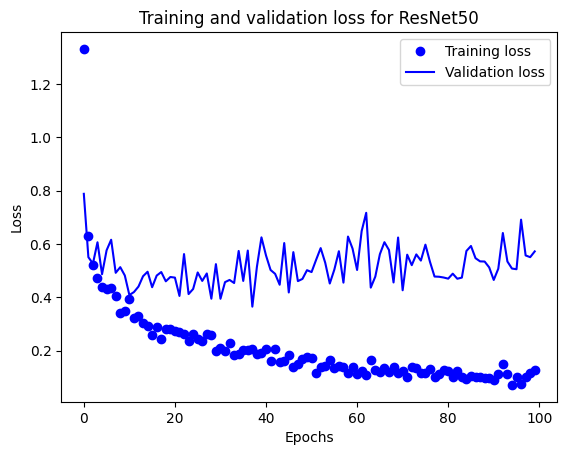

In [ ]:
import matplotlib.pyplot as plt
#PLOT
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy for ResNet50 ')
plt.xlabel('Epochs')    
plt.ylabel('Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss for ResNet50')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()